In [166]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np


df = pd.read_csv('D:\Steam_top1000\Data\steam_games_2026.csv')


<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\camer\AppData\Local\Temp\ipykernel_25148\3419562342.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  df = pd.read_csv('D:\Steam_top1000\Data\steam_games_2026.csv')


In [167]:
df.head()
df.info()
print(df.shape)


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AppID              1000 non-null   int64  
 1   Name               1000 non-null   str    
 2   Release_Date       999 non-null    str    
 3   Primary_Genre      1000 non-null   str    
 4   All_Tags           986 non-null    str    
 5   Price_USD          1000 non-null   float64
 6   Discount_Pct       1000 non-null   int64  
 7   Review_Score_Pct   1000 non-null   int64  
 8   Total_Reviews      1000 non-null   int64  
 9   Steam_Deck_Status  1000 non-null   str    
 10  Estimated_Owners   1000 non-null   int64  
 11  24h_Peak_Players   1000 non-null   int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 93.9 KB
(1000, 12)


In [168]:
df_val = df['Name'].value_counts
df_des = df['Price_USD'].describe

print(df_val)
print(df_des)

<bound method IndexOpsMixin.value_counts of 0                      Counter-Strike 2
1                      Slay the Spire 2
2                        Crimson Desert
3                              Marathon
4                 Resident Evil Requiem
                     ...               
995                         Paleo Pines
996              MARVEL Cosmic Invasion
997    Door Kickers 2: Task Force North
998                        Labyrinthine
999                              Vellum
Name: Name, Length: 1000, dtype: str>
<bound method NDFrame.describe of 0      0
1     25
2     70
3     40
4     70
      ..
995    7
996   30
997   25
998   10
999   12
Name: Price_USD, Length: 1000, dtype: float64>


In [169]:
df.loc[2, ['Name', 'Price_USD']]


Name         Crimson Desert
Price_USD                70
Name: 2, dtype: object

In [170]:
df.iloc[0:3, 0:5]

,AppID,Name,Release_Date,Primary_Genre,All_Tags
0,730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...
1,2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...
2,3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...


In [171]:
df.sort_values(by= 'Name')

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
787,3768760,007 First Light,2026-05-27,Action,Singleplayer;Action;Adventure;Action-Adventure...,70,0,0,0,Unknown,0,0
893,1895900,1348 Ex Voto,2026-03-12,Action,Singleplayer;Third Person;Medieval;Action-Adve...,22,10,51,417,Unknown,12510,0
210,251570,7 Days to Die,2024-07-25,Action,Survival;Zombies;Multiplayer;Open World;Open W...,45,0,85,270508,Unknown,8115240,17045
851,1629520,A Little to the Left,2022-11-08,Casual,Puzzle;Relaxing;Cute;Casual;Singleplayer;Point...,15,0,93,15287,Unknown,458610,422
374,1222700,A Way Out,2020-06-18,Action,Online Co-Op;Co-op;Split Screen;Story Rich;Loc...,3,90,88,72109,Unknown,2163270,262
...,...,...,...,...,...,...,...,...,...,...,...,...
525,3226450,iRacing Arcade,2026-03-03,Racing,Racing;Arcade;Driving;Automobile Sim;Managemen...,25,0,72,695,Unknown,20850,0
207,2456740,inZOI,2025-03-27,Adventure,Life Sim;Character Customization;Simulation;Re...,40,0,74,26794,Unknown,803820,1039
926,590830,s&box,April 2026,Action,Sandbox;Casual;Game Development;Building;Level...,0,0,0,0,Unknown,0,0
231,3354750,skate.,2025-09-16,Action,Multiplayer;Skateboarding;Action;Free to Play;...,0,0,50,266,Unknown,7980,0


In [172]:
df = df.drop('All_Tags', axis =1)
df.rename(columns ={'Primary_Genre': 'P_Genre'}, inplace=True)
print(df)

       AppID                              Name Release_Date    P_Genre  \
0        730                  Counter-Strike 2   2012-08-21     Action   
1    2868840                  Slay the Spire 2   2026-03-05      Indie   
2    3321460                    Crimson Desert   2026-03-19     Action   
3    3065800                          Marathon   2026-03-05     Action   
4    3764200             Resident Evil Requiem   2026-02-26     Action   
..       ...                               ...          ...        ...   
995  1202200                       Paleo Pines   2023-09-26  Adventure   
996  2753970            MARVEL Cosmic Invasion   2025-12-01     Action   
997  1239080  Door Kickers 2: Task Force North   2025-02-10     Action   
998  1302240                      Labyrinthine   2023-08-18     Action   
999   917950                            Vellum   2025-05-02     Action   

     Price_USD  Discount_Pct  Review_Score_Pct  Total_Reviews  \
0            0             0                83

In [173]:
df.dtypes


AppID                  int64
Name                     str
Release_Date             str
P_Genre                  str
Price_USD            float64
Discount_Pct           int64
Review_Score_Pct       int64
Total_Reviews          int64
Steam_Deck_Status        str
Estimated_Owners       int64
24h_Peak_Players       int64
dtype: object

In [174]:
df.isna()

,AppID,Name,Release_Date,P_Genre,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False


In [175]:
df.isnull()

,AppID,Name,Release_Date,P_Genre,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False


In [176]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

Question= Are games loosing out on sales do to poor optimization for older/weaker hardware?

In [177]:
df.groupby('Name')['Total_Reviews'].mean().sort_values(ascending=False)

Name
Counter-Strike 2                 4,980,365
PUBG: BATTLEGROUNDS              1,757,549
Tom Clancy's Rainbow Six Siege   1,234,092
Terraria                         1,201,073
Rust                             1,116,689
                                    ...   
Old School RuneScape                     0
Out of the Park Baseball 27              0
Once Human                               0
s&box                                    0
007 First Light                          0
Name: Total_Reviews, Length: 1000, dtype: float64

In [178]:
df.groupby('Name')['24h_Peak_Players'].mean().sort_values(ascending=False)

Name
Counter-Strike 2          1,013,936
Dota 2                      623,941
PUBG: BATTLEGROUNDS         314,682
ELDEN RING NIGHTREIGN       163,599
Rust                        143,870
                             ...   
AETHUS                            0
Where Winds Meet                  0
Umamusume: Pretty Derby           0
WWE 2K26                          0
Alchemy Factory                   0
Name: 24h_Peak_Players, Length: 1000, dtype: float64

I needed to get hardware info from Steam, however the Steam Hardware Survey did not have an API I could call. Below is a small excerpt of the scraper I built, this can be found in the steam_hardware_scraper.py file. 

In [179]:
# for name, row_selector, detail_selector in targets:
    
#     row = stats.find_element(By.CSS_SELECTOR, row_selector)
#     driver.execute_script("arguments[0].click();", row)

    
#     wait.until(lambda d: d.find_element(By.CSS_SELECTOR, detail_selector).text.strip() != "")

   
#     title = row.find_element(By.CSS_SELECTOR, ".stats_col_left").text.strip()

    
#     details = stats.find_element(By.CSS_SELECTOR, detail_selector).text.strip()

#     results[name] = {
#         "title": title,
#         "details": details
#     }

In [180]:
df_hardware = pd.read_csv("D:\Steam_top1000\Data\hw_survey.csv")

df_hardware.head()
df_hardware.info()
df_hardware.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  182 non-null    int64
 1   Items       182 non-null    str  
 2   Name        182 non-null    str  
 3   Percent     182 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.8 KB


<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\camer\AppData\Local\Temp\ipykernel_25148\2165406673.py:1: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  df_hardware = pd.read_csv("D:\Steam_top1000\Data\hw_survey.csv")


Unnamed: 0    int64
Items           str
Name            str
Percent         str
dtype: object

In [181]:
df_hardware["Percent"] = (
    df_hardware["Percent"]
    .str.rstrip("%")
    .pipe(pd.to_numeric, errors="coerce")/100
)
df_hardware.info()
df_hardware

<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  182 non-null    int64  
 1   Items       182 non-null    str    
 2   Name        182 non-null    str    
 3   Percent     182 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 5.8 KB


,Unnamed: 0,Items,Name,Percent
0,0,OS Version,Windows,1
1,1,OS Version,Windows 11 64 bit,1
2,2,OS Version,Windows 10 64 bit,0
3,3,OS Version,Windows 7 64 bit,0
4,4,OS Version,OSX,0
...,...,...,...,...
177,177,Video Card Description,AMD AMD Custom GPU 0405,0
178,178,Video Card Description,Intel(R) Graphics,0
179,179,Video Card Description,AMD Radeon Graphics,0
180,180,Video Card Description,NVIDIA GeForce RTX 4060,0


In [182]:
df_hardware = df_hardware.drop('Unnamed: 0', axis = 1)

df_hardware.head()

,Items,Name,Percent
0,OS Version,Windows,1
1,OS Version,Windows 11 64 bit,1
2,OS Version,Windows 10 64 bit,0
3,OS Version,Windows 7 64 bit,0
4,OS Version,OSX,0


Is there any correlation between Physical CPUs and RAM amount? 

In [183]:
df_phs_cr = df_hardware[df_hardware["Items"] =="Physical CPUs"]
df_ram = df_hardware[df_hardware["Items"]=="System RAM"]

df_phs_cr = df_phs_cr[df_phs_cr["Percent"] > 0.01]
df_phs_cr["Name"] = df_phs_cr["Name"].str.replace(" cpus", "", regex=False).astype(int)


In [184]:
df_phs_cr

,Items,Name,Percent
38,Physical CPUs,2,0
40,Physical CPUs,4,0
42,Physical CPUs,6,0
44,Physical CPUs,8,0
46,Physical CPUs,10,0
48,Physical CPUs,12,0
50,Physical CPUs,14,0
52,Physical CPUs,16,0
56,Physical CPUs,20,0
60,Physical CPUs,24,0


In [185]:
df_ram

,Items,Name,Percent
24,System RAM,Less than 4 GB,0
25,System RAM,4 GB,0
26,System RAM,8 GB,0
27,System RAM,12 GB,0
28,System RAM,16 GB,0
29,System RAM,24 GB,0
30,System RAM,28 GB,0
31,System RAM,32 GB,0
32,System RAM,48 GB,0
33,System RAM,60 GB,0


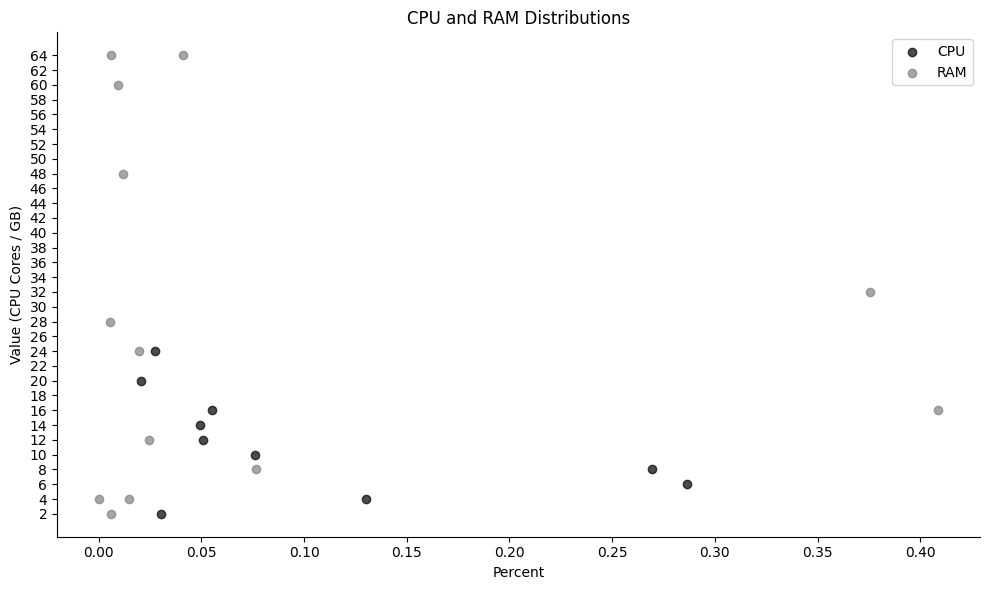

In [186]:
df_phs_cr = df_hardware[df_hardware["Items"] == "Physical CPUs"].copy()
df_phs_cr = df_phs_cr[df_phs_cr["Percent"] > 0.01].copy()

df_phs_cr["value"] = df_phs_cr["Name"].str.extract(r"(\d+)").astype(int)
df_phs_cr["type"] = "CPU"


df_ram = df_hardware[df_hardware["Items"] == "System RAM"].copy()

df_ram["value"] = df_ram["Name"].str.extract(r"(\d+)")
df_ram["value"] = df_ram["value"].fillna(2).astype(int)  # handles "Less than 4 GB"
df_ram["type"] = "RAM"


df_all = pd.concat([df_phs_cr, df_ram])


plt.figure(figsize=(10, 6))

colors = {"CPU": "black", "RAM": "gray"}

for t in df_all["type"].unique():
    subset = df_all[df_all["type"] == t]
    plt.scatter(
        subset["Percent"],
        subset["value"],
        label=t,
        color=colors[t],
        alpha=0.7
    )

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("CPU and RAM Distributions")
plt.xlabel("Percent")
plt.ylabel("Value (CPU Cores / GB)")
plt.legend()
plt.yticks(np.arange(df_all["value"].min(), df_all["value"].max() + 1, 2))

plt.tight_layout()
plt.show()

There does not appear to be any main correlation between Core count and RAM size. As most in the hardware survey are using 6 core and 8 core CPus, which would typically be considered lower end or the more budget oriented CPUs. However The RAM size(s) with the most would be 16 GB and 32 GB. While 32 GB is considered more midrange, games and productivity aplications are increasingly more demanding forcing many to move towards 32 GB of RAM as the new standard "Acceptable amount" (Possibly able to see a correlation between amount of users using 32 GB of RAM and newer minimum requirements for applications)

In [187]:
df.head()

,AppID,Name,Release_Date,P_Genre,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,730,Counter-Strike 2,2012-08-21,Action,0,0,83,4980365,Unknown,149410950,1013936
1,2868840,Slay the Spire 2,2026-03-05,Indie,25,0,97,49549,Unknown,1486470,0
2,3321460,Crimson Desert,2026-03-19,Action,70,0,0,0,Unknown,0,0
3,3065800,Marathon,2026-03-05,Action,40,0,90,24360,Unknown,730800,0
4,3764200,Resident Evil Requiem,2026-02-26,Action,70,0,96,79667,Unknown,2390010,0


In [188]:
df.dtypes

AppID                  int64
Name                     str
Release_Date             str
P_Genre                  str
Price_USD            float64
Discount_Pct           int64
Review_Score_Pct       int64
Total_Reviews          int64
Steam_Deck_Status        str
Estimated_Owners       int64
24h_Peak_Players       int64
dtype: object

In [189]:
df = df.drop(columns=['Steam_Deck_Status','AppID'])

df.head()

,Name,Release_Date,P_Genre,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,0,0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,25,0,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,70,0,0,0,0,0
3,Marathon,2026-03-05,Action,40,0,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,70,0,96,79667,2390010,0


In [190]:
df.describe()


,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
count,"1,000","1,000","1,000","1,000","1,000","1,000"
mean,22,18,80,"63,871","1,916,136","5,213"
std,19,29,19,"211,588","6,347,638","40,375"
min,0,0,0,0,0,0
25%,8,0,75,"1,638","49,148",0
50%,20,0,85,"11,732","351,960",286
75%,30,35,92,"48,516","1,455,472","1,601"
max,70,95,100,"4,980,365","149,410,950","1,013,936"


In [191]:
df_zero_count = (df == 0).sum()
df_zero_count


Name                  0
Release_Date          0
P_Genre               0
Price_USD           108
Discount_Pct        658
Review_Score_Pct     31
Total_Reviews       102
Estimated_Owners    102
24h_Peak_Players    304
dtype: int64

In [192]:
df = df.drop('Discount_Pct', axis= 1)

df

,Name,Release_Date,P_Genre,Price_USD,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,25,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,70,0,0,0,0
3,Marathon,2026-03-05,Action,40,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,70,96,79667,2390010,0
...,...,...,...,...,...,...,...,...
995,Paleo Pines,2023-09-26,Adventure,7,93,1921,57630,50
996,MARVEL Cosmic Invasion,2025-12-01,Action,30,90,1630,48900,0
997,Door Kickers 2: Task Force North,2025-02-10,Action,25,96,11539,346170,505
998,Labyrinthine,2023-08-18,Action,10,70,13549,406470,179


Do Steam Users tend to play less expensive games over more expensive? 

In [193]:
pd.set_option('display.float_format', '{:,.0f}'.format)
df_grp_pr_own = df.groupby('Price_USD')['Estimated_Owners'].mean()


df_grp_pr_own

Price_USD
0    2,567,829
0            0
1            0
1            0
1       36,651
        ...   
45   2,738,025
49     193,770
50   1,983,931
60   3,915,769
70     921,367
Name: Estimated_Owners, Length: 99, dtype: float64

In [194]:
df_grp_pr_o = df.groupby('Price_USD')['Estimated_Owners'].mean().max()

df_grp_pr_o

np.float64(5657010.0)

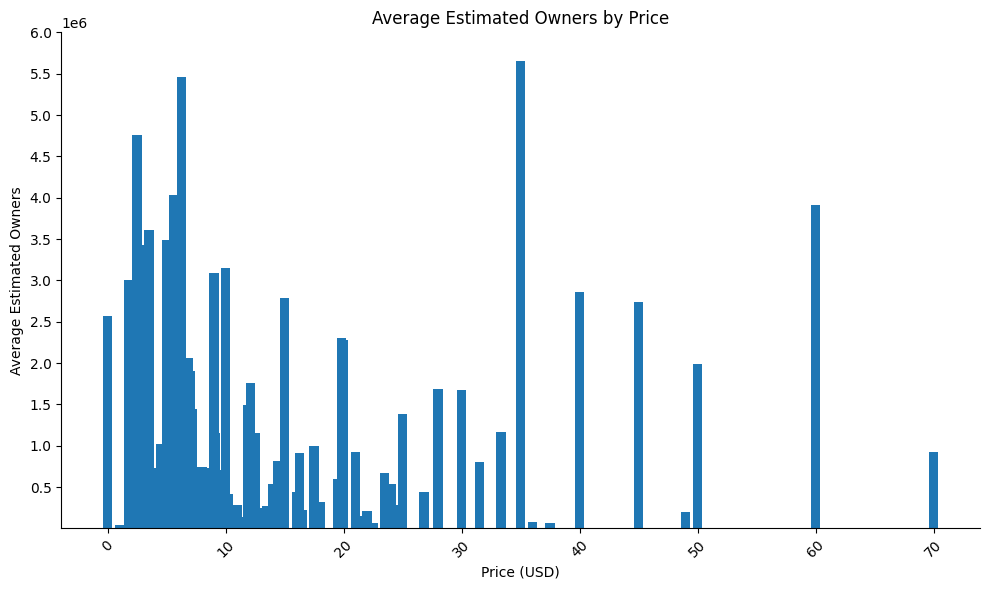

In [195]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_grp_pr_own.index,
    df_grp_pr_own.values,

)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.xlabel("Price (USD)")
plt.ylabel("Average Estimated Owners")
plt.title("Average Estimated Owners by Price")

plt.xticks(rotation=45)
plt.yticks(
    [
        500000,
        1000000,
        1500000, 
        2000000, 
        2500000, 
        3000000, 
        3500000, 
        4000000, 
        4500000, 
        5000000, 
        5500000, 
        6000000
    ]
)
plt.tight_layout()
plt.show()

Surprisingly games that are free or less than $20.00 USD are not the most owned. It seems games targeted between $30.00 USD to $40.00 USD see the most sales, although the $0.00 USD to $ $10.00 USD range is right behind it in Estimated owners. Could this be why many new games target the $30.00 USD to $40.00 USD range? (Need to compare release date by estimated owners and price)

What games are most players getting based on price? 

In [196]:
df.head()

,Name,Release_Date,P_Genre,Price_USD,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0,Counter-Strike 2,2012-08-21,Action,0,83,4980365,149410950,1013936
1,Slay the Spire 2,2026-03-05,Indie,25,97,49549,1486470,0
2,Crimson Desert,2026-03-19,Action,70,0,0,0,0
3,Marathon,2026-03-05,Action,40,90,24360,730800,0
4,Resident Evil Requiem,2026-02-26,Action,70,96,79667,2390010,0


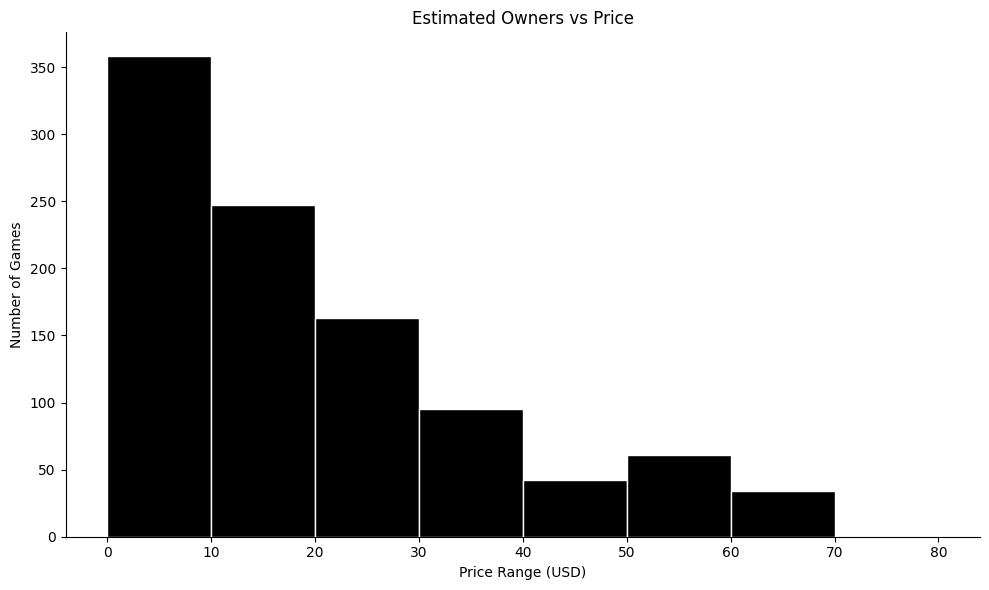

In [198]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Price_USD'],
    bins=[0,10,20,30,40,50,60,70,80],
    edgecolor='white',
    color= "black"
)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Price Range (USD)")
plt.ylabel("Number of Games")
plt.title("Estimated Owners vs Price")

plt.xticks([0,10,20,30,40,50,60,70,80])

plt.tight_layout()
plt.show()

Unsurprisingly, the majority of games in the top 1,000 are less then $20, with the most owned being between $0.00 USD to $10.00 USD